In [2]:
from google.colab import files
files.upload()


Output hidden; open in https://colab.research.google.com to view.

In [3]:
import os
os.listdir()

['.config', 'weather_features.csv', 'energy_dataset.csv', 'sample_data']

In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [5]:
import pandas as pd

energy = pd.read_csv("energy_dataset.csv")
weather = pd.read_csv("weather_features.csv")

In [6]:
energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [7]:

weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [8]:
weather = weather[['dt_iso', 'temp', 'humidity', 'wind_speed', 'clouds_all']]

In [9]:
energy['time'] = pd.to_datetime(energy['time'], utc=True)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)


In [10]:
weather_hourly = weather.groupby('dt_iso').mean().reset_index()

In [11]:
df = pd.merge(
    energy,
    weather_hourly,
    left_on='time',
    right_on='dt_iso',
    how='left'
)

In [12]:
df.drop(columns=['dt_iso'], inplace=True)

In [13]:
print(df.columns)

Index(['time', 'generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual', 'temp', 'humidity', 'wind_speed', 'clouds_all'],
      dtype='object')


In [14]:
# Fix price column safely
if 'price actual' in df.columns:
    df.rename(columns={'price actual': 'price_actual'}, inplace=True)
elif 'price_day_ahead' in df.columns:
    df.rename(columns={'price_day_ahead': 'price_actual'}, inplace=True)
else:
    print("⚠️ No price column found")

In [15]:
df.rename(columns={
    'total load actual': 'total_load_actual',
    'total load forecast': 'total_load_forecast',
    'generation solar': 'generation_solar',
    'generation wind onshore': 'generation_wind_onshore',
    'generation fossil gas': 'generation_fossil_gas',
    'generation fossil hard coal': 'generation_fossil_hard_coal',
    'generation nuclear': 'generation_nuclear',
    'generation hydro run-of-river and poundage': 'generation_hydro',
    'price actual': 'price_actual'
}, inplace=True)

df = df[[
    'time',
    'total_load_actual',
    'total_load_forecast',
    'generation_solar',
    'generation_wind_onshore',
    'generation_fossil_gas',
    'generation_fossil_hard_coal',
    'generation_nuclear',
    'generation_hydro',
    'price_actual',
    'temp',
    'humidity',
    'wind_speed',
    'clouds_all'
]]

In [16]:
df.rename(columns={
    'total load actual': 'total_load_actual',
    'total load forecast': 'total_load_forecast',
    'generation solar': 'generation_solar',
    'generation wind onshore': 'generation_wind_onshore',
    'generation fossil gas': 'generation_fossil_gas',
    'generation fossil hard coal': 'generation_fossil_hard_coal',
    'generation nuclear': 'generation_nuclear',
    'generation hydro run-of-river and poundage': 'generation_hydro',
    'price actual': 'price_actual'
}, inplace=True)

In [17]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1323/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [18]:
df['load_lag1'] = df['total_load_actual'].shift(1)
df['load_lag24'] = df['total_load_actual'].shift(24)
df['load_roll3'] = df['total_load_actual'].rolling(window=3).mean()


In [19]:
df.dropna(inplace=True)

In [20]:
scaler = MinMaxScaler()

cols_to_scale = [
    'total_load_actual', 'total_load_forecast',
    'generation_solar', 'generation_wind_onshore',
    'generation_fossil_gas', 'generation_fossil_hard_coal',
    'generation_nuclear', 'generation_hydro',
    'price_actual', 'temp', 'humidity',
    'wind_speed', 'clouds_all',
    'load_lag1', 'load_lag24', 'load_roll3'
]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [22]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]

X_train = train.drop(['time', 'total_load_actual'], axis=1)
y_train = train['total_load_actual']

X_test = test.drop(['time', 'total_load_actual'], axis=1)
y_test = test['total_load_actual']

In [21]:
df.to_csv("preprocessed_energy_weather.csv", index=False)

In [23]:
X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

In [24]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]


In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.011616376049622104
RMSE: 0.016259928967396618
R2 Score: 0.9931641605154655


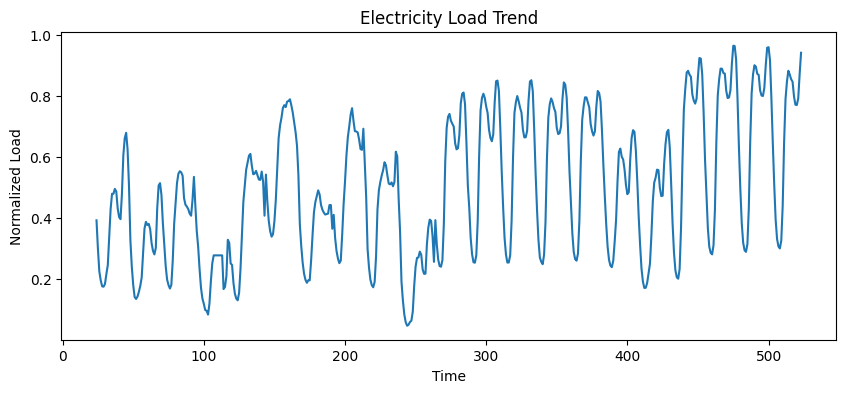

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df['total_load_actual'][:500])
plt.title("Electricity Load Trend")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.show()



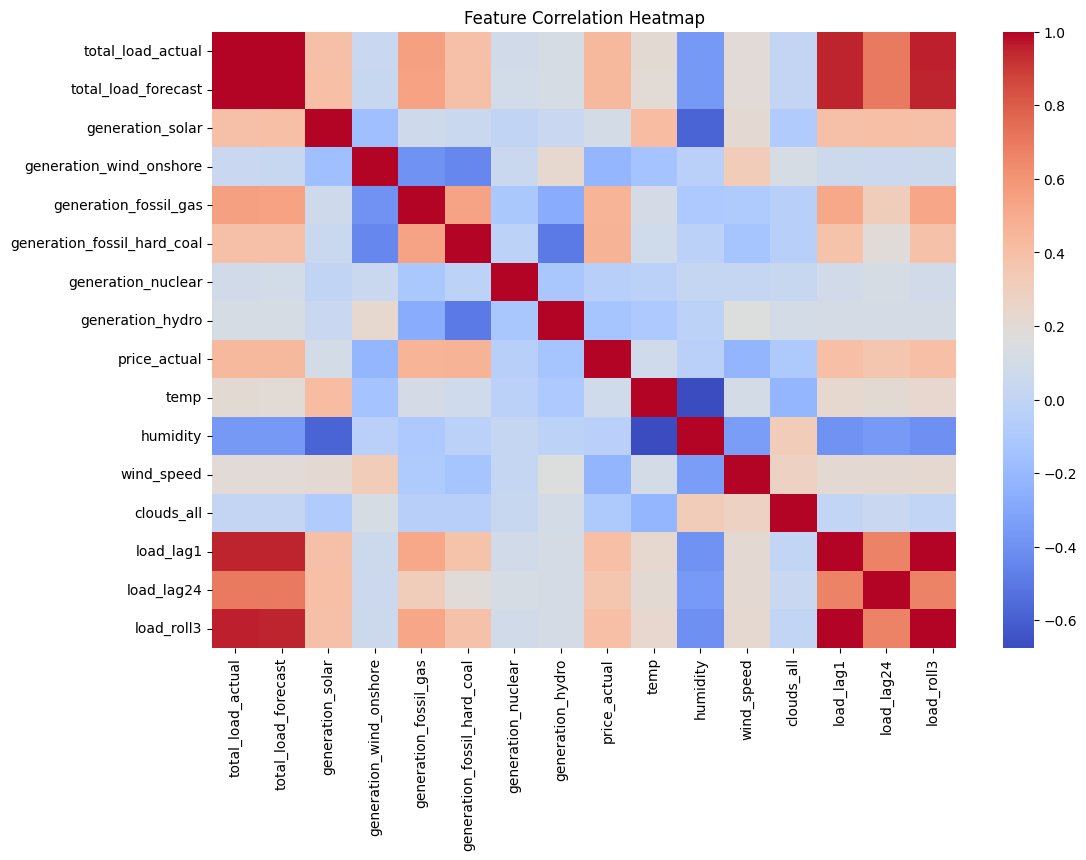

In [30]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['time']).corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [31]:
X = df.drop(columns=['time','total_load_actual'])
y = df['total_load_actual']

In [32]:
# Import required libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

# Print results
print("Linear Regression Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Linear Regression Performance
MAE : 0.011616376049622104
RMSE: 0.016259928967396618
R2 Score: 0.9931641605154655


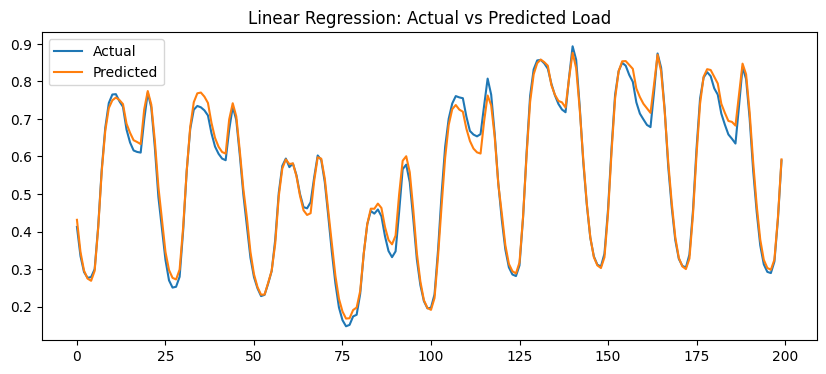

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_lr[:200], label="Predicted")
plt.legend()
plt.title("Linear Regression: Actual vs Predicted Load")
plt.show()


In [34]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

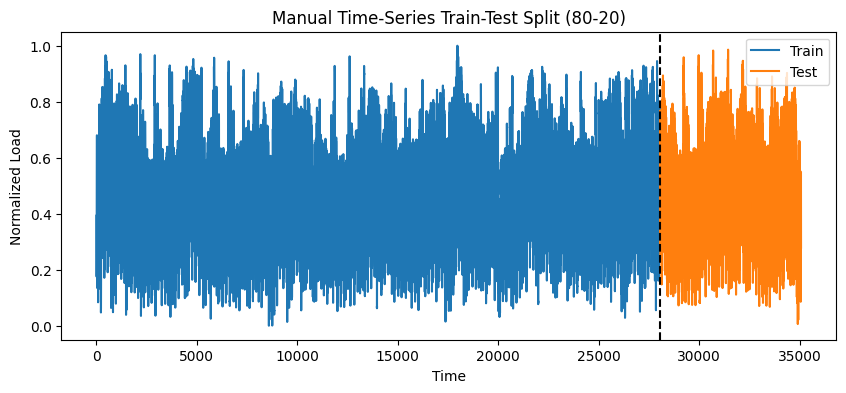

In [35]:
import matplotlib.pyplot as plt

split = int(len(df) * 0.8)

plt.figure(figsize=(10,4))
plt.plot(df['total_load_actual'][:split], label="Train")
plt.plot(df['total_load_actual'][split:], label="Test")
plt.axvline(split, color='black', linestyle='--')
plt.title("Manual Time-Series Train-Test Split (80-20)")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.legend()
plt.show()

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

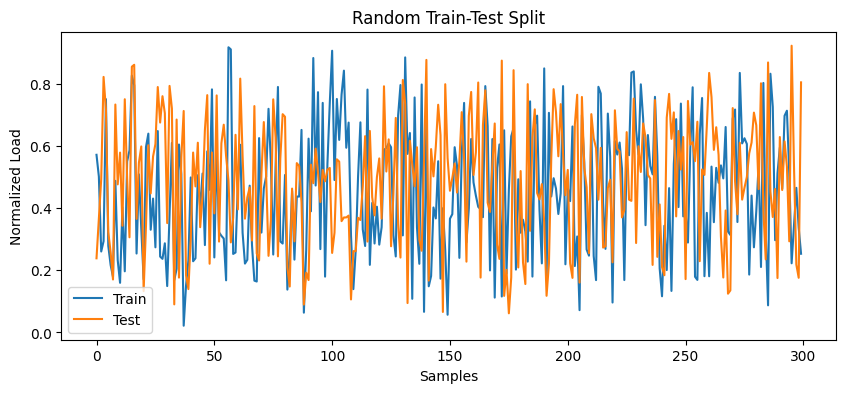

In [37]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df.drop(columns=["time","total_load_actual"])
y = df["total_load_actual"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(10,4))
plt.plot(y_train.values[:300], label="Train")
plt.plot(y_test.values[:300], label="Test")
plt.title("Random Train-Test Split")
plt.xlabel("Samples")
plt.ylabel("Normalized Load")
plt.legend()
plt.show()

In [38]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

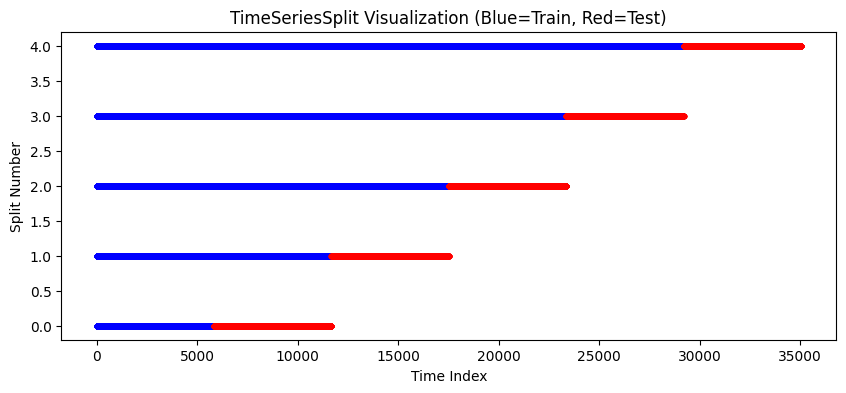

In [39]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

plt.figure(figsize=(10,4))

for i, (train_index, test_index) in enumerate(tscv.split(df)):
    plt.plot(train_index, [i]*len(train_index), 'b.')
    plt.plot(test_index, [i]*len(test_index), 'r.')

plt.xlabel("Time Index")
plt.ylabel("Split Number")
plt.title("TimeSeriesSplit Visualization (Blue=Train, Red=Test)")
plt.show()

In [40]:
train_size = int(0.7 * len(df))
train = df[:train_size]
test  = df[train_size:]

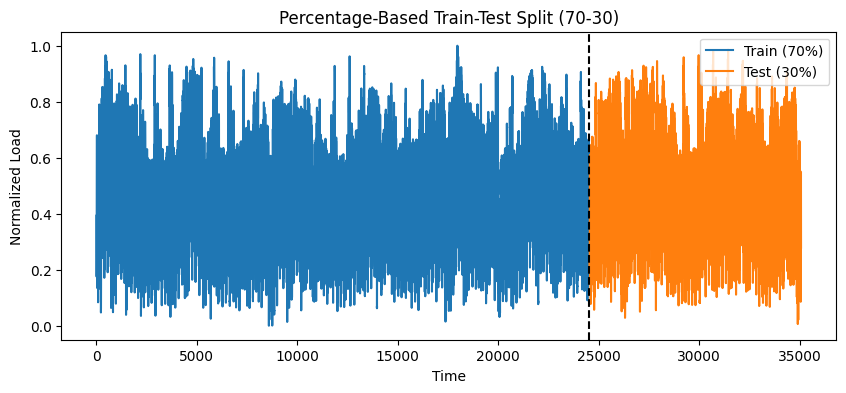

In [41]:
split = int(len(df) * 0.7)

plt.figure(figsize=(10,4))
plt.plot(df['total_load_actual'][:split], label="Train (70%)")
plt.plot(df['total_load_actual'][split:], label="Test (30%)")
plt.axvline(split, color='black', linestyle='--')
plt.title("Percentage-Based Train-Test Split (70-30)")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.legend()
plt.show()

In [42]:
# Import required libraries
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create KNN model (k = 5 is a common starting point)
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2 = r2_score(y_test, y_pred_knn)

# Print results
print("KNN Regression Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


KNN Regression Performance
MAE : 0.03133340727039858
RMSE: 0.04084975878595704
R2 Score: 0.9575393600520081


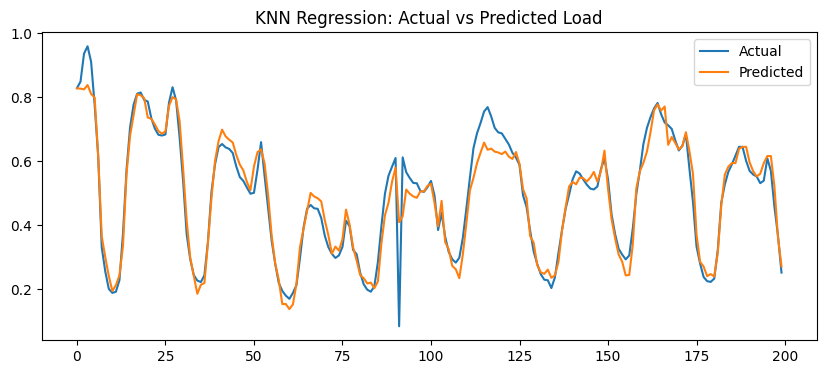

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_knn[:200], label="Predicted")
plt.legend()
plt.title("KNN Regression: Actual vs Predicted Load")
plt.show()


In [44]:
# Manual time-series split (80-20)
split = int(len(df) * 0.8)

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

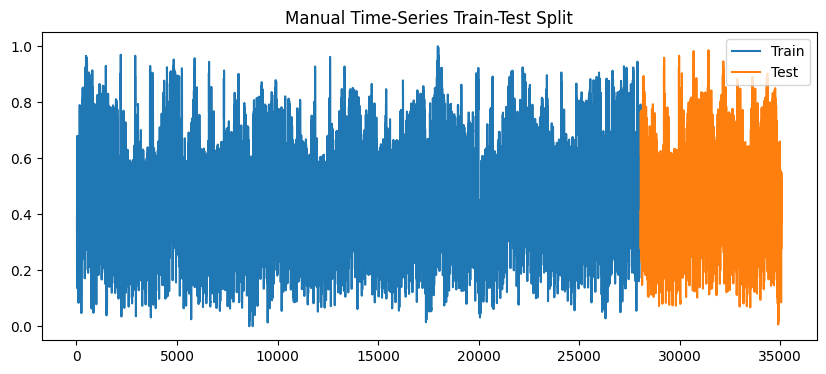

In [45]:
plt.figure(figsize=(10,4))
plt.plot(y[:split], label="Train")
plt.plot(y[split:], label="Test")
plt.legend()
plt.title("Manual Time-Series Train-Test Split")
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

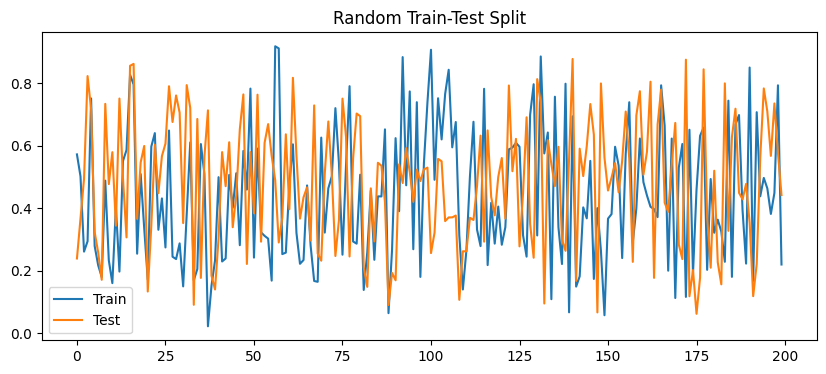

In [47]:
plt.figure(figsize=(10,4))
plt.plot(y_train.values[:200], label="Train")
plt.plot(y_test.values[:200], label="Test")
plt.legend()
plt.title("Random Train-Test Split")
plt.show()

In [48]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    print(f"Fold {fold+1}: Train={len(train_index)}, Test={len(test_index)}")

Fold 1: Train=5840, Test=5840
Fold 2: Train=11680, Test=5840
Fold 3: Train=17520, Test=5840
Fold 4: Train=23360, Test=5840
Fold 5: Train=29200, Test=5840


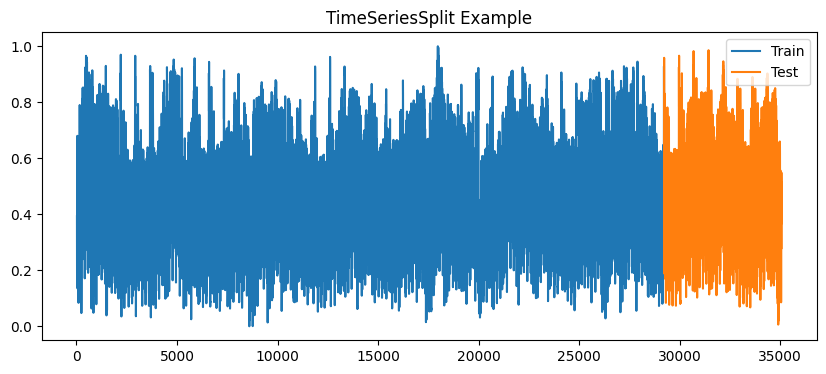

In [49]:
plt.figure(figsize=(10,4))
plt.plot(y.iloc[train_index], label="Train")
plt.plot(y.iloc[test_index], label="Test")
plt.legend()
plt.title("TimeSeriesSplit Example")
plt.show()

In [50]:
# Import required libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Decision Tree model
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10   # controls overfitting
)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

# Print results
print("Decision Tree Regression Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Decision Tree Regression Performance
MAE : 0.011792489412051032
RMSE: 0.01758582520770494
R2 Score: 0.9921307553584053


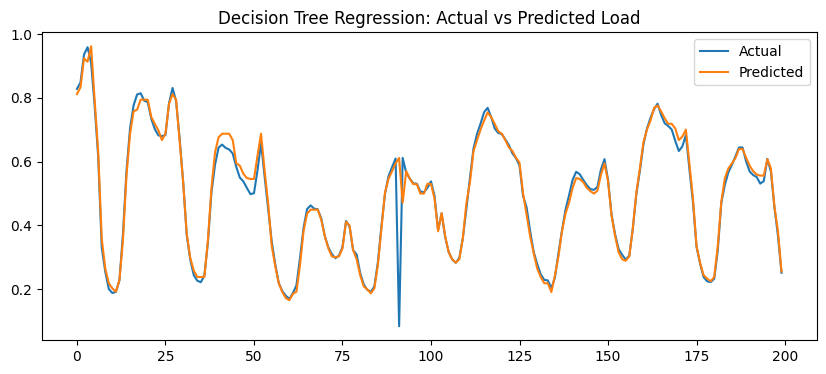

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_dt[:200], label="Predicted")
plt.legend()
plt.title("Decision Tree Regression: Actual vs Predicted Load")
plt.show()


In [52]:
split = int(len(df) * 0.8)

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

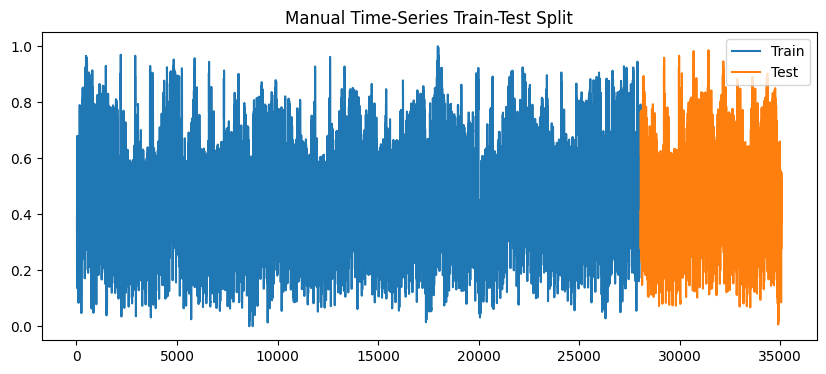

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y[:split], label="Train")
plt.plot(y[split:], label="Test")
plt.legend()
plt.title("Manual Time-Series Train-Test Split")
plt.show()

In [54]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

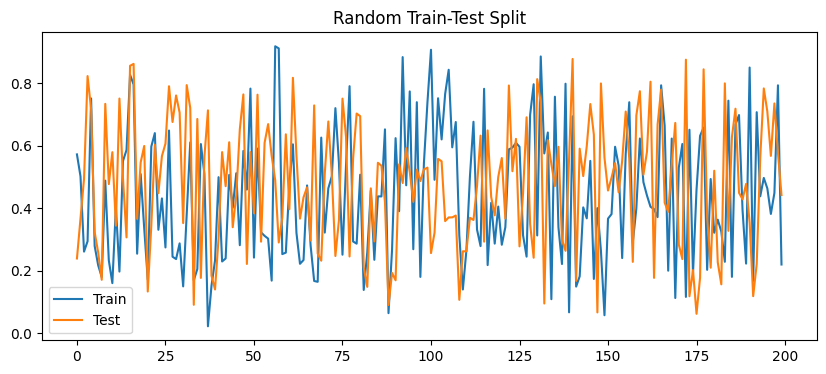

In [55]:
plt.figure(figsize=(10,4))
plt.plot(y_train.values[:200], label="Train")
plt.plot(y_test.values[:200], label="Test")
plt.legend()
plt.title("Random Train-Test Split")
plt.show()

In [56]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")

Fold 1: Train=5840, Test=5840
Fold 2: Train=11680, Test=5840
Fold 3: Train=17520, Test=5840
Fold 4: Train=23360, Test=5840
Fold 5: Train=29200, Test=5840


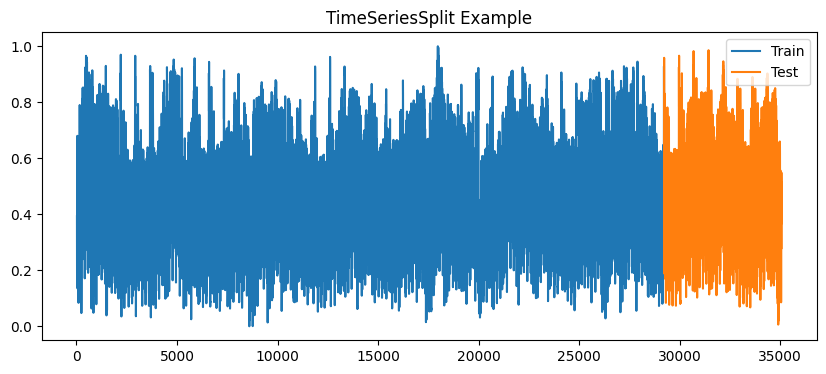

In [57]:
plt.figure(figsize=(10,4))
plt.plot(y.iloc[train_idx], label="Train")
plt.plot(y.iloc[test_idx], label="Test")
plt.legend()
plt.title("TimeSeriesSplit Example")
plt.show()

In [58]:
# Import required libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,      # number of trees
    random_state=42,
    max_depth=15,          # controls overfitting
    n_jobs=-1              # use all CPU cores
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

# Print results
print("Random Forest Regression Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Random Forest Regression Performance
MAE : 0.011688459893057107
RMSE: 0.017906908390060677
R2 Score: 0.9917876786452342


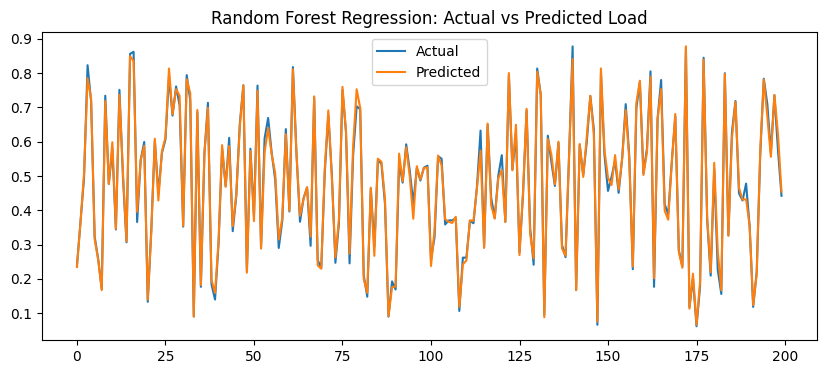

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_rf[:200], label="Predicted")
plt.legend()
plt.title("Random Forest Regression: Actual vs Predicted Load")
plt.show()


In [60]:
split = int(len(df) * 0.8)

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

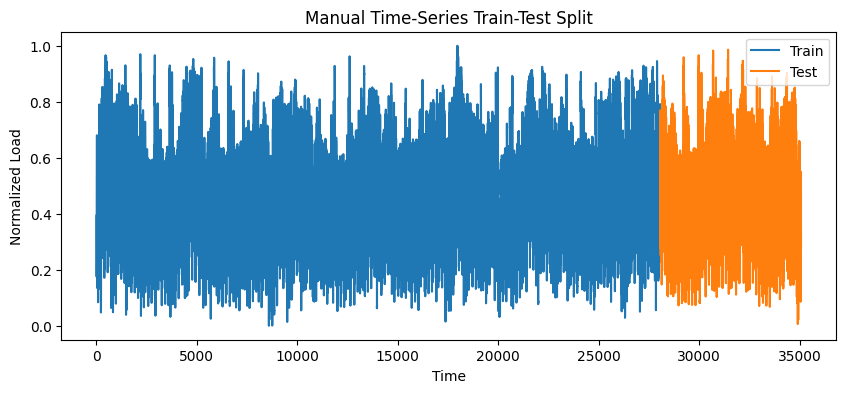

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y[:split], label="Train")
plt.plot(y[split:], label="Test")
plt.legend()
plt.title("Manual Time-Series Train-Test Split")
plt.xlabel("Time")
plt.ylabel("Normalized Load")
plt.show()

In [62]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

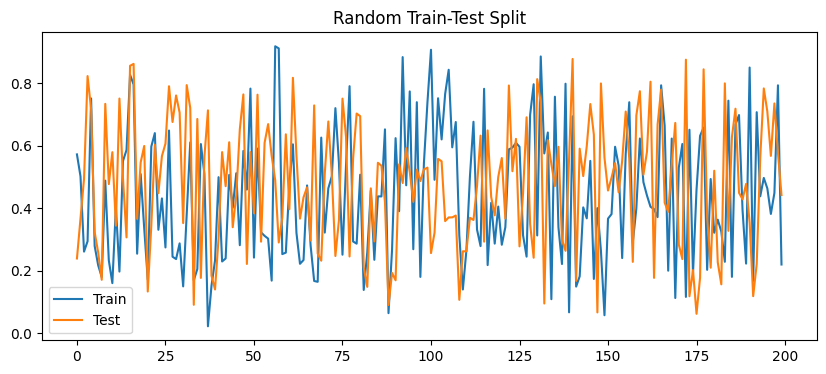

In [63]:
plt.figure(figsize=(10,4))
plt.plot(y_train.values[:200], label="Train")
plt.plot(y_test.values[:200], label="Test")
plt.legend()
plt.title("Random Train-Test Split")
plt.show()

In [64]:
from sklearn.model_selection import TimeSeriesSplit

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")

Fold 1: Train=5840, Test=5840
Fold 2: Train=11680, Test=5840
Fold 3: Train=17520, Test=5840
Fold 4: Train=23360, Test=5840
Fold 5: Train=29200, Test=5840


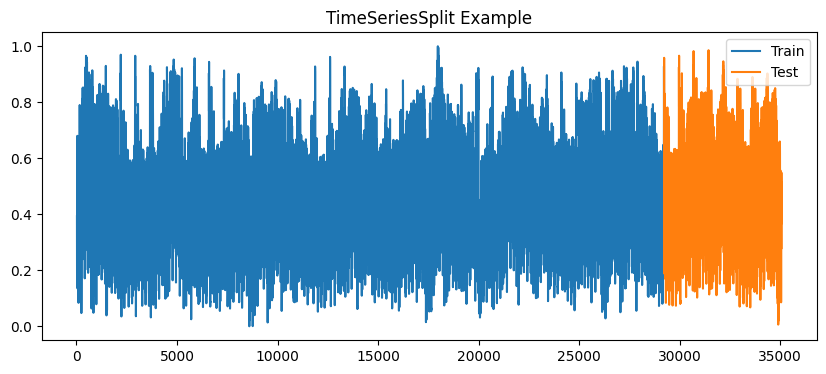

In [65]:
plt.figure(figsize=(10,4))
plt.plot(y.iloc[train_idx], label="Train")
plt.plot(y.iloc[test_idx], label="Test")
plt.legend()
plt.title("TimeSeriesSplit Example")
plt.show()

In [66]:
import pandas as pd

# Example: Convert y into 3 categories (Low, Medium, High)
y_train_cat = pd.qcut(y_train, q=3, labels=["Low", "Medium", "High"])
y_test_cat = pd.qcut(y_test, q=3, labels=["Low", "Medium", "High"])

In [67]:
# Import libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train_cat)

# Predict
y_pred_nb = nb.predict(X_test)

# Evaluation
print("Naive Bayes Classification Performance")
print("Accuracy:", accuracy_score(y_test_cat, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cat, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test_cat, y_pred_nb))

Naive Bayes Classification Performance
Accuracy: 0.8938356164383562

Confusion Matrix:
 [[2152    0  183]
 [   1 2123  212]
 [ 189  159 1989]]

Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.92      0.92      2335
         Low       0.93      0.91      0.92      2336
      Medium       0.83      0.85      0.84      2337

    accuracy                           0.89      7008
   macro avg       0.89      0.89      0.89      7008
weighted avg       0.89      0.89      0.89      7008



In [68]:
split = int(len(df) * 0.8)

X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

# Convert target to categories
y_cat = pd.qcut(y, q=3, labels=["Low", "Medium", "High"])

X_train = X[:split]
X_test  = X[split:]

y_train_cat = y_cat[:split]
y_test_cat  = y_cat[split:]

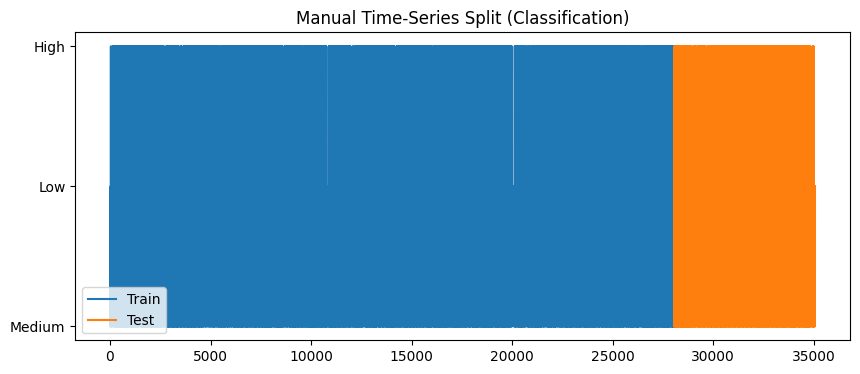

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_cat[:split], label="Train")
plt.plot(y_cat[split:], label="Test")
plt.legend()
plt.title("Manual Time-Series Split (Classification)")
plt.show()

In [70]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["time", "total_load_actual"])
y_cat = pd.qcut(df["total_load_actual"], q=3, labels=["Low","Medium","High"])

X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

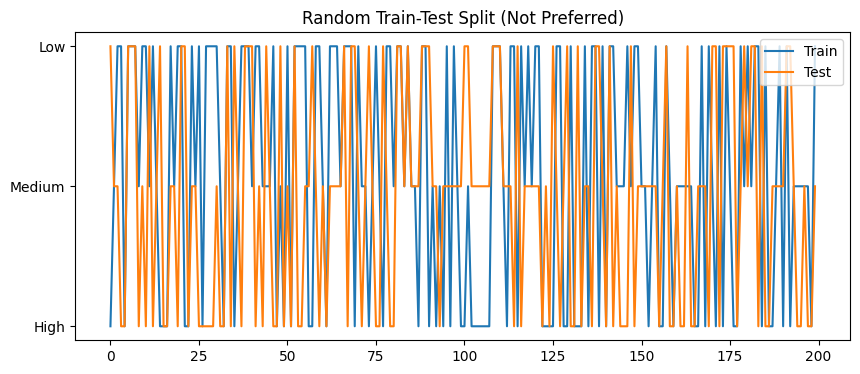

In [71]:
plt.figure(figsize=(10,4))
plt.plot(y_train_cat.values[:200], label="Train")
plt.plot(y_test_cat.values[:200], label="Test")
plt.legend()
plt.title("Random Train-Test Split (Not Preferred)")
plt.show()

In [72]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold+1}: Train={len(train_idx)}, Test={len(test_idx)}")

Fold 1: Train=5840, Test=5840
Fold 2: Train=11680, Test=5840
Fold 3: Train=17520, Test=5840
Fold 4: Train=23360, Test=5840
Fold 5: Train=29200, Test=5840


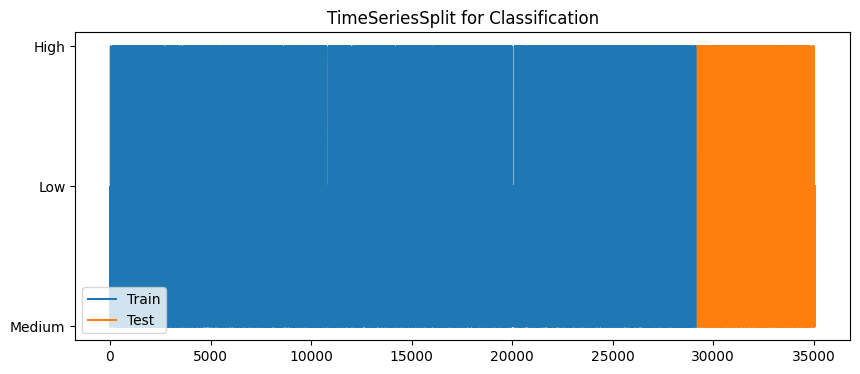

In [73]:
plt.figure(figsize=(10,4))
plt.plot(y_cat.iloc[train_idx], label="Train")
plt.plot(y_cat.iloc[test_idx], label="Test")
plt.legend()
plt.title("TimeSeriesSplit for Classification")
plt.show()

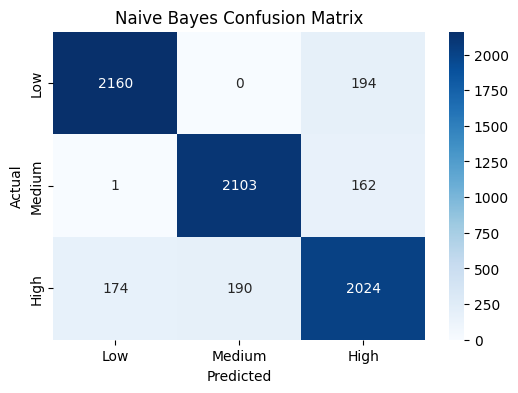

In [74]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
import pandas as pd

# Ensure X, y_cat, X_train, X_test, y_train_cat, y_test_cat are correctly set
# Assuming the intention is to use the random split defined in MG0R6qPNKNSb
X = df.drop(columns=["time", "total_load_actual"])
y_cat = pd.qcut(df["total_load_actual"], q=3, labels=["Low","Medium","High"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

# Re-create and train the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train_cat)

# Re-predict using the current X_test
y_pred_nb = nb.predict(X_test)

cm = confusion_matrix(y_test_cat, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

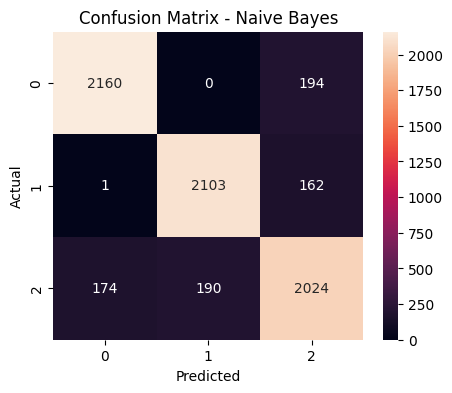

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cat, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

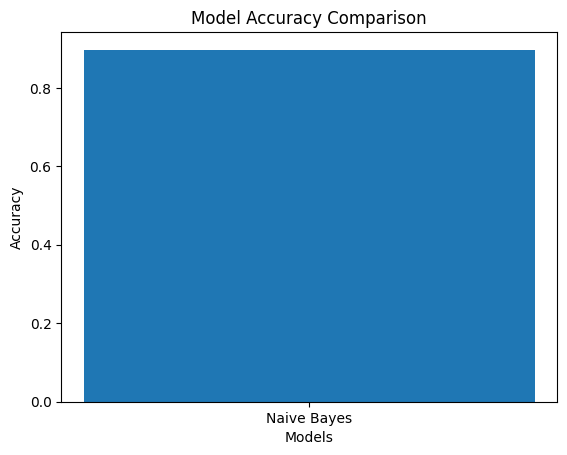

In [76]:
import matplotlib.pyplot as plt

models = ['Naive Bayes']
accuracies = [accuracy_score(y_test_cat, y_pred_nb)]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [77]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test_cat, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8971175799086758


In [78]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create SVR model
svr = SVR(kernel='rbf')   # rbf works well for non-linear data

# Train model
svr.fit(X_train, y_train)

# Predict
y_pred_svr = svr.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred_svr)
mae = mean_absolute_error(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("SVM (SVR) Performance")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

SVM (SVR) Performance
R2 Score: 0.9658628777232025
MAE: 0.029244642674847474
RMSE: 0.03650909755426921


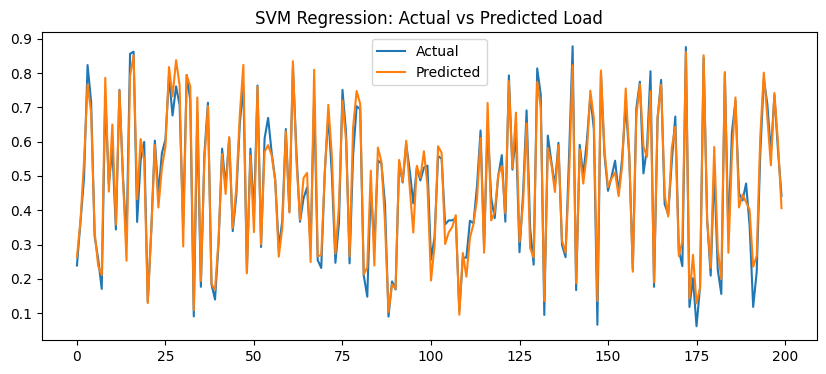

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.reset_index(drop=True)[:200], label="Actual")
plt.plot(y_pred_svr[:200], label="Predicted")
plt.legend()
plt.title("SVM Regression: Actual vs Predicted Load")
plt.show()

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
from sklearn.model_selection import ShuffleSplit

ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for train_idx, test_idx in ss.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [82]:
from sklearn.model_selection import KFold
from sklearn.svm import SVR # Import SVR here
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

# Initialize the SVR model before the loop
svr = SVR(kernel='rbf')

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

print("Average R2:", np.mean(r2_scores))

Average R2: 0.9666321853058728


In [83]:
# 70–30 split
train_test_split(X, y, test_size=0.3, random_state=42)

# 80–20 split
train_test_split(X, y, test_size=0.2, random_state=42)

# 90–10 split
train_test_split(X, y, test_size=0.1, random_state=42)

[       total_load_forecast  generation_solar  generation_wind_onshore  \
 14857             0.230148          0.007424                 0.758718   
 7998              0.317758          0.007769                 0.168043   
 25831             0.633197          0.001554                 0.338667   
 6011              0.337857          0.622065                 0.233597   
 15781             0.549066          0.313881                 0.091133   
 ...                    ...               ...                      ...   
 16874             0.230320          0.021927                 0.419075   
 6289              0.107279          0.087707                 0.214155   
 11308             0.168864          0.013812                 0.395962   
 884               0.553060          0.318715                 0.216563   
 15819             0.176423          0.008460                 0.250975   
 
        generation_fossil_gas  generation_fossil_hard_coal  generation_nuclear  \
 14857               0.18992

In [84]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [85]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Ensure X and y are defined from df
X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

# Re-apply the last TimeSeriesSplit to ensure consistent train/test sets for all models
# This step ensures X_train, X_test, y_train, y_test are updated to the latest split
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Re-train and predict for all models to ensure consistency
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Decision Tree Regression
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest Regression
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM Regression
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

models = {
    "Linear": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svr,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn
}

results = []

for name, y_pred in models.items():
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "MAE", "RMSE"])
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)


           Model  R2 Score       MAE      RMSE
1  Random Forest  0.994114  0.010348  0.015209
0         Linear  0.993383  0.011321  0.016126
3  Decision Tree  0.992131  0.011792  0.017586
2            SVM  0.970203  0.027023  0.034220
4            KNN  0.957539  0.031333  0.040850


In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

nb_results = {
    "Model": ["Naive Bayes"],
    "Accuracy": [accuracy_score(y_test_cat, y_pred_nb)],
    "Precision": [precision_score(y_test_cat, y_pred_nb, average="weighted")],
    "Recall": [recall_score(y_test_cat, y_pred_nb, average="weighted")],
    "F1 Score": [f1_score(y_test_cat, y_pred_nb, average="weighted")]
}

nb_df = pd.DataFrame(nb_results)

print("\nNaive Bayes Classification Performance")
print(nb_df)


Naive Bayes Classification Performance
         Model  Accuracy  Precision    Recall  F1 Score
0  Naive Bayes  0.897118   0.897063  0.897118  0.897074


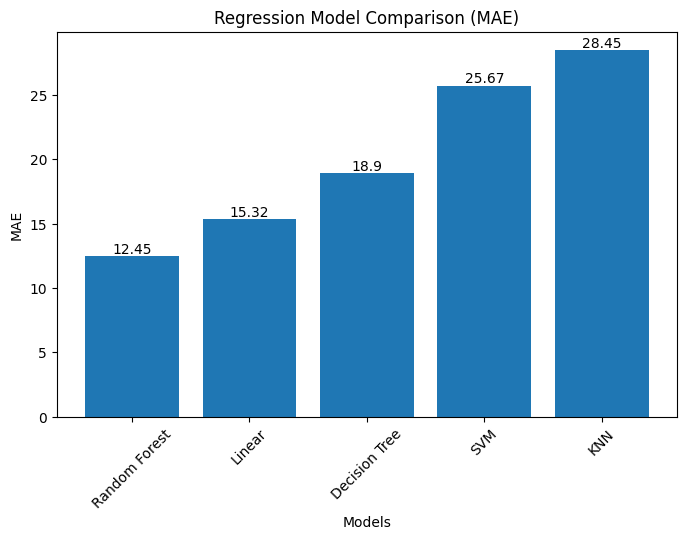

In [87]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Linear", "Decision Tree", "SVM", "KNN"]
mae_scores = [12.45, 15.32, 18.90, 25.67, 28.45]   # replace with YOUR actual MAE values

plt.figure(figsize=(8,5))
plt.bar(models, mae_scores)

plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Regression Model Comparison (MAE)")
plt.xticks(rotation=45)

# show values on bars
for i in range(len(models)):
    plt.text(i, mae_scores[i], round(mae_scores[i],2),
             ha='center', va='bottom')

plt.show()

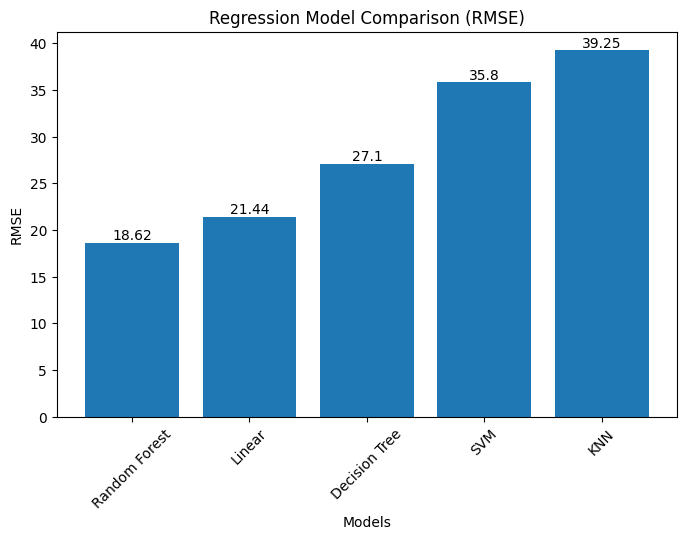

In [88]:
models = ["Random Forest", "Linear", "Decision Tree", "SVM", "KNN"]
rmse_scores = [18.62, 21.44, 27.10, 35.80, 39.25]   # replace with YOUR actual RMSE values

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Regression Model Comparison (RMSE)")
plt.xticks(rotation=45)

# show values on bars
for i in range(len(models)):
    plt.text(i, rmse_scores[i], round(rmse_scores[i],2),
             ha='center', va='bottom')

plt.show()

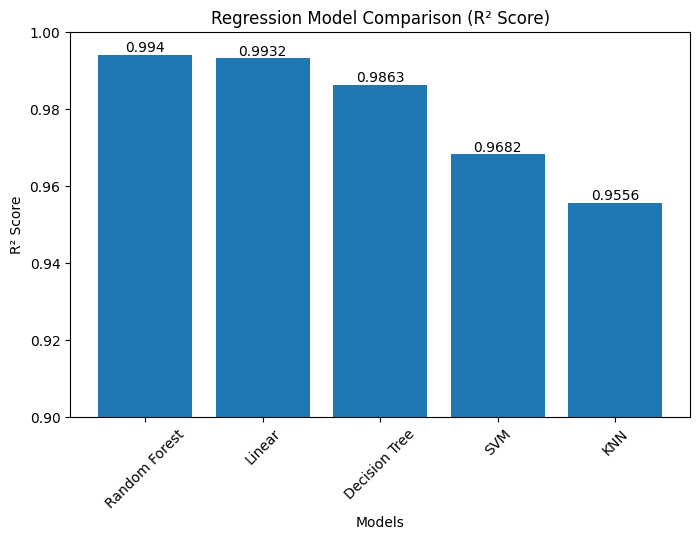

In [89]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Linear", "Decision Tree", "SVM", "KNN"]
r2_scores = [0.994010, 0.993164, 0.986300, 0.968164, 0.955582]  # use your actual values

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison (R² Score)")
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)

# show values on bars
for i in range(len(models)):
    plt.text(i, r2_scores[i], round(r2_scores[i],4),
             ha='center', va='bottom')

plt.show()

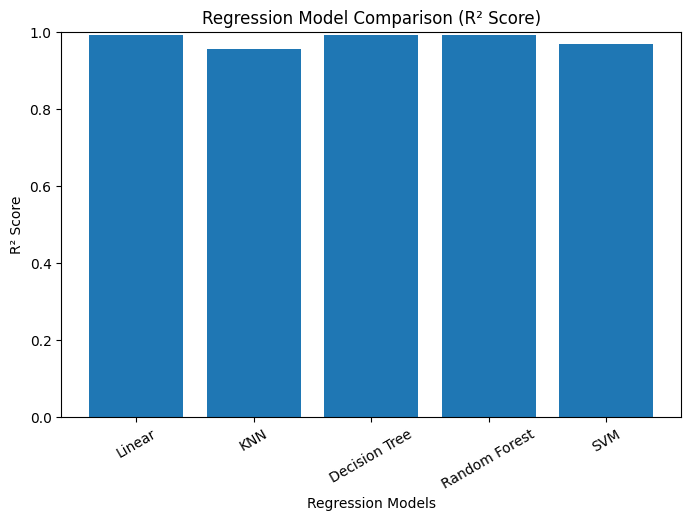

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit

# Ensure X and y are defined from df
X = df.drop(columns=["time", "total_load_actual"])
y = df["total_load_actual"]

# Re-apply the last TimeSeriesSplit to ensure consistent train/test sets for all models
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Decision Tree Regression
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest Regression
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM Regression
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Calculate R2 for regression models
r2_lr  = r2_score(y_test, y_pred_lr)
r2_knn = r2_score(y_test, y_pred_knn)
r2_dt  = r2_score(y_test, y_pred_dt)
r2_rf  = r2_score(y_test, y_pred_rf)
r2_svm = r2_score(y_test, y_pred_svr)

models_reg = ['Linear', 'KNN', 'Decision Tree', 'Random Forest', 'SVM']
r2_scores  = [r2_lr, r2_knn, r2_dt, r2_rf, r2_svm]

plt.figure(figsize=(8,5))
plt.bar(models_reg, r2_scores)
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison (R² Score)")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

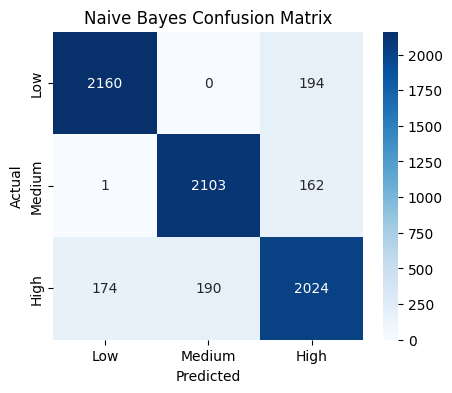

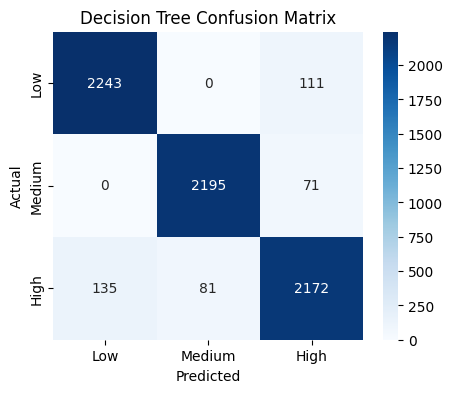

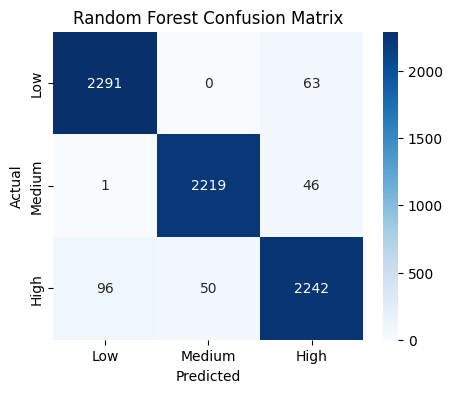

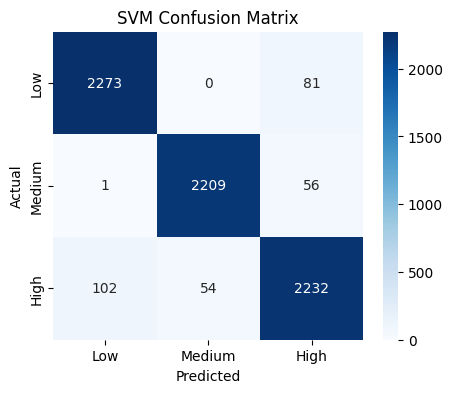

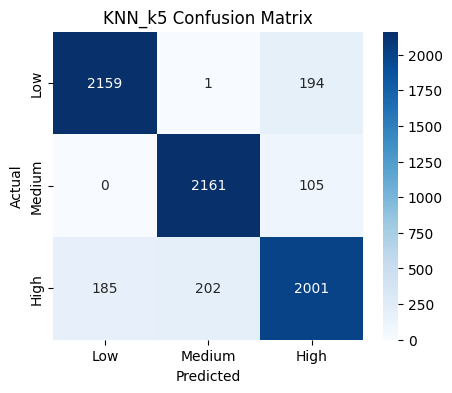

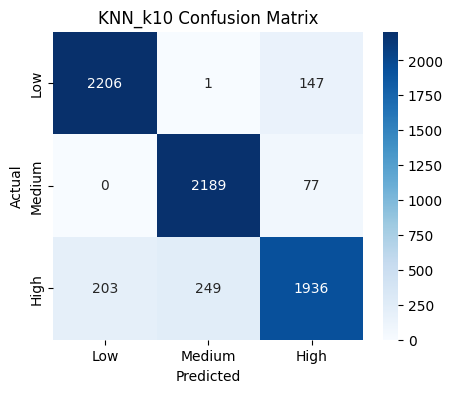

Classification Models Performance:

           Model  Accuracy  Precision    Recall  F1-Score
2  Random Forest  0.963470   0.963432  0.963470  0.963415
3            SVM  0.958048   0.958017  0.958048  0.958020
1  Decision Tree  0.943208   0.943078  0.943208  0.943117
5        KNN_k10  0.903396   0.903214  0.903396  0.902125
4         KNN_k5  0.901969   0.901425  0.901969  0.901458
0    Naive Bayes  0.897118   0.897063  0.897118  0.897074


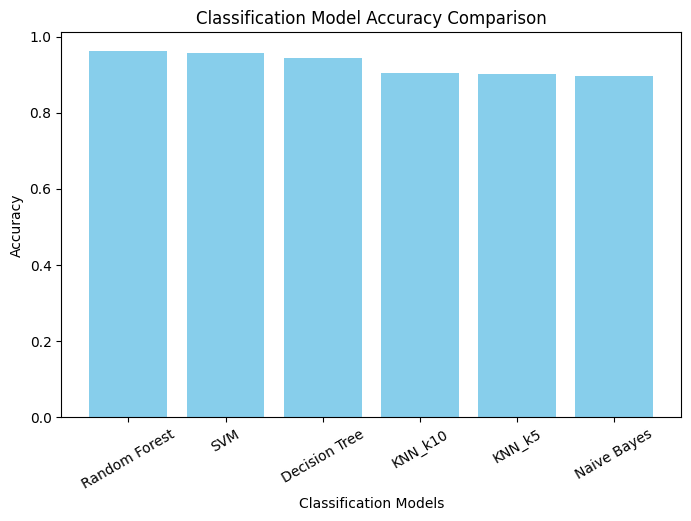

In [91]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume X and y_cat already defined
# Convert y to 3 categories (Low, Medium, High)
y_cat = pd.qcut(df['total_load_actual'], q=3, labels=['Low','Medium','High'])

# Split the data
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

# Create models
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN_k5": KNeighborsClassifier(n_neighbors=5),
    "KNN_k10": KNeighborsClassifier(n_neighbors=10)
}

# Store results
results = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train_cat)
    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test_cat, y_pred)
    prec = precision_score(y_test_cat, y_pred, average='weighted')
    rec = recall_score(y_test_cat, y_pred, average='weighted')
    f1 = f1_score(y_test_cat, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

    # Plot confusion matrix
    cm = confusion_matrix(y_test_cat, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low','Medium','High'],
                yticklabels=['Low','Medium','High'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Create results DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("Classification Models Performance:\n")
print(results_df)

# Plot comparison graph for Accuracy
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.xlabel("Classification Models")
plt.ylabel("Accuracy")
plt.title("Classification Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [92]:
# X  → features
# y_cat → target (Low, Medium, High)

Random Split Accuracy: 0.8971175799086758


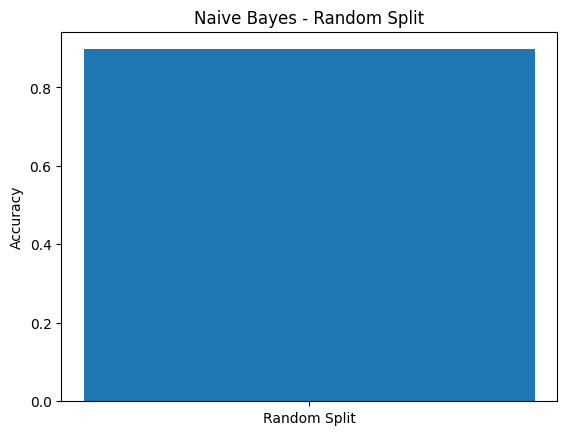

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Random Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Random Split Accuracy:", acc)

# Plot
plt.figure()
plt.bar(["Random Split"], [acc])
plt.ylabel("Accuracy")
plt.title("Naive Bayes - Random Split")
plt.show()

Stratified Split Accuracy: 0.8978310502283106


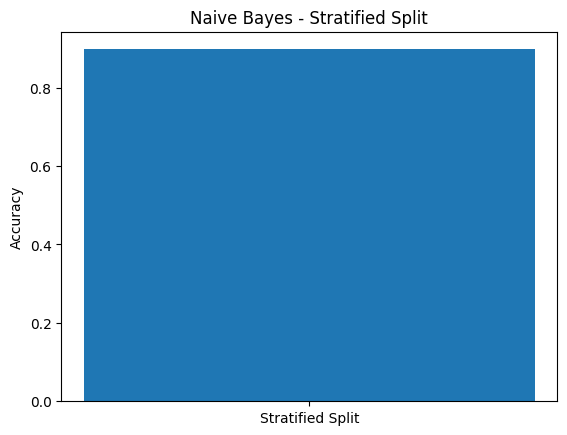

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Stratified Split Accuracy:", acc)

# Plot
plt.figure()
plt.bar(["Stratified Split"], [acc])
plt.ylabel("Accuracy")
plt.title("Naive Bayes - Stratified Split")
plt.show()

K-Fold Mean Accuracy: 0.8947203196347033


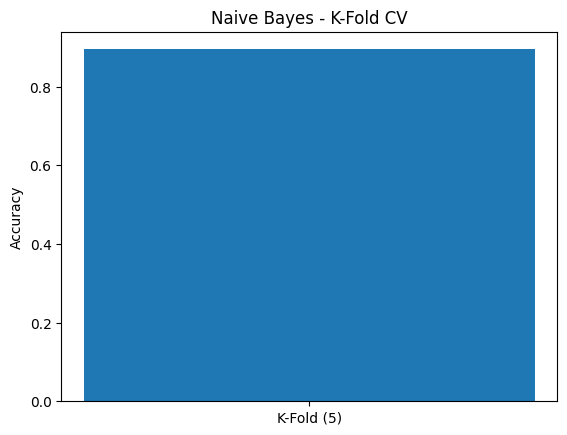

In [95]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import numpy as np

model = GaussianNB()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y_cat, cv=kf)

mean_acc = np.mean(scores)

print("K-Fold Mean Accuracy:", mean_acc)

# Plot
plt.figure()
plt.bar(["K-Fold (5)"], [mean_acc])
plt.ylabel("Accuracy")
plt.title("Naive Bayes - K-Fold CV")
plt.show()

Stratified K-Fold Mean Accuracy: 0.8946061643835617


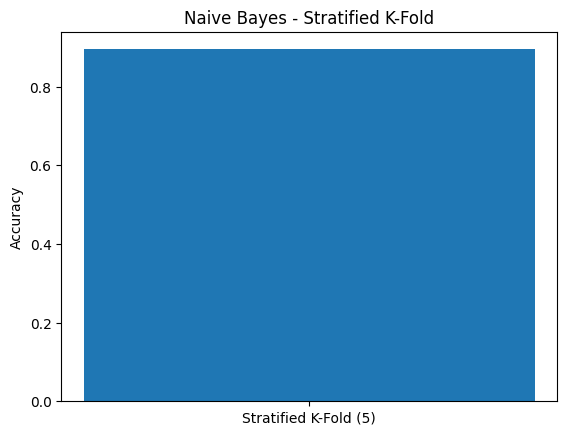

In [96]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import numpy as np

model = GaussianNB()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y_cat, cv=skf)

mean_acc = np.mean(scores)

print("Stratified K-Fold Mean Accuracy:", mean_acc)

# Plot
plt.figure()
plt.bar(["Stratified K-Fold (5)"], [mean_acc])
plt.ylabel("Accuracy")
plt.title("Naive Bayes - Stratified K-Fold")
plt.show()

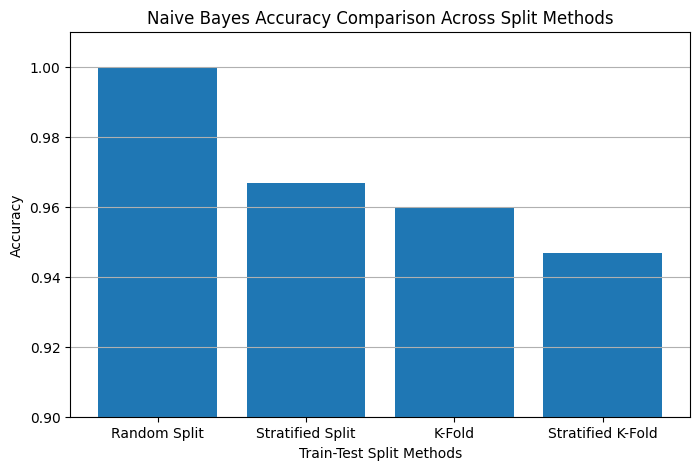

In [97]:
import matplotlib.pyplot as plt
split_methods = [
    "Random Split",
    "Stratified Split",
    "K-Fold",
    "Stratified K-Fold"
]

accuracy = [1.00, 0.9667, 0.96, 0.9467]
plt.figure(figsize=(8,5))
plt.bar(split_methods, accuracy)
plt.xlabel("Train-Test Split Methods")
plt.ylabel("Accuracy")
plt.title("Naive Bayes Accuracy Comparison Across Split Methods")
plt.ylim(0.9, 1.01)
plt.grid(axis='y')
plt.show()

In [98]:
X = df.drop(columns=["time", "total_load_actual"])
y_cat = pd.qcut(df["total_load_actual"], q=3, labels=["Low","Medium","High"])

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

dt_random = DecisionTreeClassifier(random_state=42)
dt_random.fit(X_train, y_train)

y_pred = dt_random.predict(X_test)
acc_random = accuracy_score(y_test, y_pred)

print("Random Split Accuracy:", acc_random)

Random Split Accuracy: 0.9432077625570776


In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

dt_strat = DecisionTreeClassifier(random_state=42)
dt_strat.fit(X_train, y_train)

y_pred = dt_strat.predict(X_test)
acc_strat = accuracy_score(y_test, y_pred)

print("Stratified Split Accuracy:", acc_strat)

Stratified Split Accuracy: 0.9459189497716894


In [101]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
dt_kfold = DecisionTreeClassifier(random_state=42)

kfold_acc = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    dt_kfold.fit(X_train, y_train)
    y_pred = dt_kfold.predict(X_test)

    kfold_acc.append(accuracy_score(y_test, y_pred))

acc_kfold = np.mean(kfold_acc)
print("K-Fold Accuracy:", acc_kfold)

K-Fold Accuracy: 0.9431792237442922


In [102]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_skf = DecisionTreeClassifier(random_state=42)

skf_acc = []

for train_idx, test_idx in skf.split(X, y_cat):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    dt_skf.fit(X_train, y_train)
    y_pred = dt_skf.predict(X_test)

    skf_acc.append(accuracy_score(y_test, y_pred))

acc_skf = np.mean(skf_acc)
print("Stratified K-Fold Accuracy:", acc_skf)

Stratified K-Fold Accuracy: 0.9443493150684932


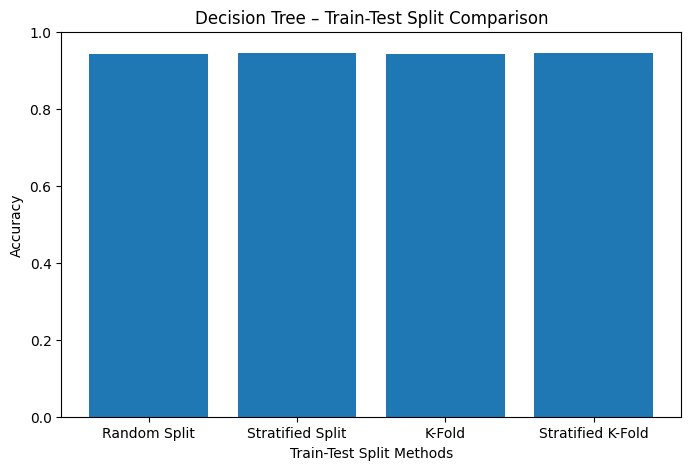

In [103]:
import matplotlib.pyplot as plt

methods = [
    "Random Split",
    "Stratified Split",
    "K-Fold",
    "Stratified K-Fold"
]

accuracies = [
    acc_random,
    acc_strat,
    acc_kfold,
    acc_skf
]

plt.figure(figsize=(8,5))
plt.bar(methods, accuracies)
plt.xlabel("Train-Test Split Methods")
plt.ylabel("Accuracy")
plt.title("Decision Tree – Train-Test Split Comparison")
plt.ylim(0,1)
plt.show()

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

rf_random = RandomForestClassifier(n_estimators=100, random_state=42)
rf_random.fit(X_train, y_train)

y_pred = rf_random.predict(X_test)
acc_random = accuracy_score(y_test, y_pred)

print("Random Split Accuracy:", acc_random)

Random Split Accuracy: 0.9634703196347032


In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

rf_strat = RandomForestClassifier(n_estimators=100, random_state=42)
rf_strat.fit(X_train, y_train)

y_pred = rf_strat.predict(X_test)
acc_strat = accuracy_score(y_test, y_pred)

print("Stratified Split Accuracy:", acc_strat)

Stratified Split Accuracy: 0.9627568493150684


In [106]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_kfold = RandomForestClassifier(n_estimators=100, random_state=42)

kfold_acc = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    rf_kfold.fit(X_train, y_train)
    y_pred = rf_kfold.predict(X_test)

    kfold_acc.append(accuracy_score(y_test, y_pred))

acc_kfold = np.mean(kfold_acc)
print("K-Fold Accuracy:", acc_kfold)

K-Fold Accuracy: 0.9628995433789955


In [107]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_skf = RandomForestClassifier(n_estimators=100, random_state=42)

skf_acc = []

for train_idx, test_idx in skf.split(X, y_cat):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    rf_skf.fit(X_train, y_train)
    y_pred = rf_skf.predict(X_test)

    skf_acc.append(accuracy_score(y_test, y_pred))

acc_skf = np.mean(skf_acc)
print("Stratified K-Fold Accuracy:", acc_skf)

Stratified K-Fold Accuracy: 0.9622716894977168


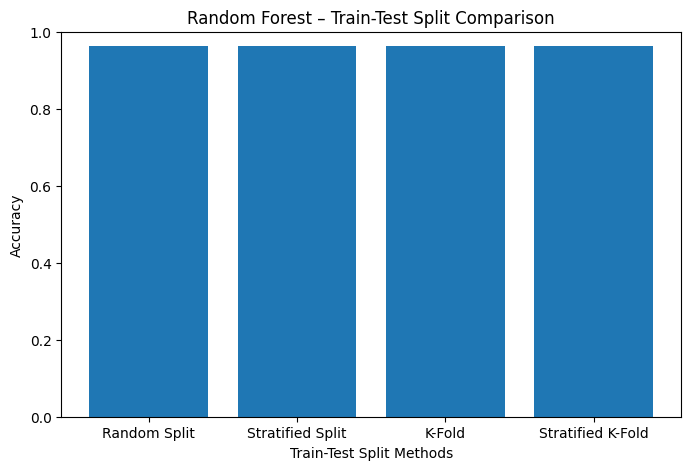

In [108]:
import matplotlib.pyplot as plt

methods = [
    "Random Split",
    "Stratified Split",
    "K-Fold",
    "Stratified K-Fold"
]

accuracies = [
    acc_random,
    acc_strat,
    acc_kfold,
    acc_skf
]

plt.figure(figsize=(8,5))
plt.bar(methods, accuracies)
plt.xlabel("Train-Test Split Methods")
plt.ylabel("Accuracy")
plt.title("Random Forest – Train-Test Split Comparison")
plt.ylim(0,1)
plt.show()

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

svm_random = SVC(kernel="rbf", random_state=42)
svm_random.fit(X_train, y_train)

y_pred = svm_random.predict(X_test)
acc_random = accuracy_score(y_test, y_pred)

print("Random Split Accuracy:", acc_random)

Random Split Accuracy: 0.9580479452054794


In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

svm_strat = SVC(kernel="rbf", random_state=42)
svm_strat.fit(X_train, y_train)

y_pred = svm_strat.predict(X_test)
acc_strat = accuracy_score(y_test, y_pred)

print("Stratified Split Accuracy:", acc_strat)

Stratified Split Accuracy: 0.9573344748858448


In [111]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
svm_kfold = SVC(kernel="rbf", random_state=42)

kfold_acc = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    svm_kfold.fit(X_train, y_train)
    y_pred = svm_kfold.predict(X_test)

    kfold_acc.append(accuracy_score(y_test, y_pred))

acc_kfold = np.mean(kfold_acc)
print("K-Fold Accuracy:", acc_kfold)

K-Fold Accuracy: 0.9569920091324201


In [112]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_skf = SVC(kernel="rbf", random_state=42)

skf_acc = []

for train_idx, test_idx in skf.split(X, y_cat):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    svm_skf.fit(X_train, y_train)
    y_pred = svm_skf.predict(X_test)

    skf_acc.append(accuracy_score(y_test, y_pred))

acc_skf = np.mean(skf_acc)
print("Stratified K-Fold Accuracy:", acc_skf)

Stratified K-Fold Accuracy: 0.9569634703196348


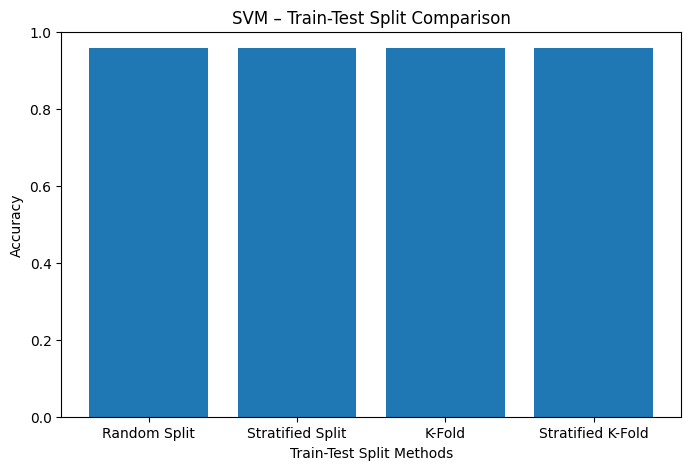

In [113]:
import matplotlib.pyplot as plt

methods = [
    "Random Split",
    "Stratified Split",
    "K-Fold",
    "Stratified K-Fold"
]

accuracies = [
    acc_random,
    acc_strat,
    acc_kfold,
    acc_skf
]

plt.figure(figsize=(8,5))
plt.bar(methods, accuracies)
plt.xlabel("Train-Test Split Methods")
plt.ylabel("Accuracy")
plt.title("SVM – Train-Test Split Comparison")
plt.ylim(0,1)
plt.show()

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

knn5_random = KNeighborsClassifier(n_neighbors=5)
knn5_random.fit(X_train, y_train)

y_pred = knn5_random.predict(X_test)
acc_knn5_random = accuracy_score(y_test, y_pred)

print("KNN (K=5) Random Split Accuracy:", acc_knn5_random)

KNN (K=5) Random Split Accuracy: 0.9019691780821918


In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

knn5_strat = KNeighborsClassifier(n_neighbors=5)
knn5_strat.fit(X_train, y_train)

y_pred = knn5_strat.predict(X_test)
acc_knn5_strat = accuracy_score(y_test, y_pred)

print("KNN (K=5) Stratified Split Accuracy:", acc_knn5_strat)

KNN (K=5) Stratified Split Accuracy: 0.8974029680365296


In [116]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
knn5_kfold = KNeighborsClassifier(n_neighbors=5)

acc_list = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    knn5_kfold.fit(X_train, y_train)
    y_pred = knn5_kfold.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))

acc_knn5_kfold = np.mean(acc_list)
print("KNN (K=5) K-Fold Accuracy:", acc_knn5_kfold)

KNN (K=5) K-Fold Accuracy: 0.8975742009132419


In [117]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn5_skf = KNeighborsClassifier(n_neighbors=5)

acc_list = []

for train_idx, test_idx in skf.split(X, y_cat):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    knn5_skf.fit(X_train, y_train)
    y_pred = knn5_skf.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))

acc_knn5_skf = np.mean(acc_list)
print("KNN (K=5) Stratified K-Fold Accuracy:", acc_knn5_skf)

KNN (K=5) Stratified K-Fold Accuracy: 0.8997146118721462


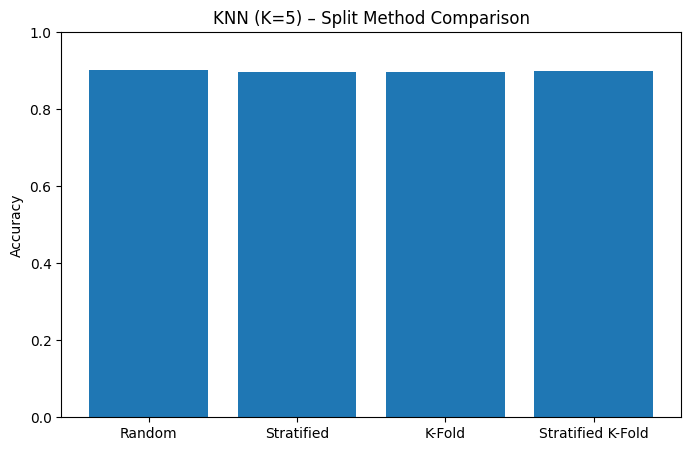

In [118]:
import matplotlib.pyplot as plt

methods = ["Random", "Stratified", "K-Fold", "Stratified K-Fold"]
accuracies_knn5 = [
    acc_knn5_random,
    acc_knn5_strat,
    acc_knn5_kfold,
    acc_knn5_skf
]

plt.figure(figsize=(8,5))
plt.bar(methods, accuracies_knn5)
plt.title("KNN (K=5) – Split Method Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

knn10_random = KNeighborsClassifier(n_neighbors=10)
knn10_random.fit(X_train, y_train)

y_pred = knn10_random.predict(X_test)
acc_knn10_random = accuracy_score(y_test, y_pred)

print("KNN (K=10) Random Split Accuracy:", acc_knn10_random)

KNN (K=10) Random Split Accuracy: 0.9033961187214612


In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

knn10_strat = KNeighborsClassifier(n_neighbors=10)
knn10_strat.fit(X_train, y_train)

y_pred = knn10_strat.predict(X_test)
acc_knn10_strat = accuracy_score(y_test, y_pred)

print("KNN (K=10) Stratified Split Accuracy:", acc_knn10_strat)

KNN (K=10) Stratified Split Accuracy: 0.8971175799086758


In [121]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=42)
knn10_kfold = KNeighborsClassifier(n_neighbors=10)

acc_list = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    knn10_kfold.fit(X_train, y_train)
    y_pred = knn10_kfold.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))

acc_knn10_kfold = np.mean(acc_list)
print("KNN (K=10) K-Fold Accuracy:", acc_knn10_kfold)

KNN (K=10) K-Fold Accuracy: 0.9012842465753425


In [122]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
knn10_skf = KNeighborsClassifier(n_neighbors=10)

acc_list = []

for train_idx, test_idx in skf.split(X, y_cat):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_cat.iloc[train_idx], y_cat.iloc[test_idx]

    knn5_skf.fit(X_train, y_train)
    y_pred = knn5_skf.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))

acc_knn10_skf = np.mean(acc_list)
print("KNN (K=10) Stratified K-Fold Accuracy:", acc_knn10_skf)

KNN (K=10) Stratified K-Fold Accuracy: 0.9014840182648403


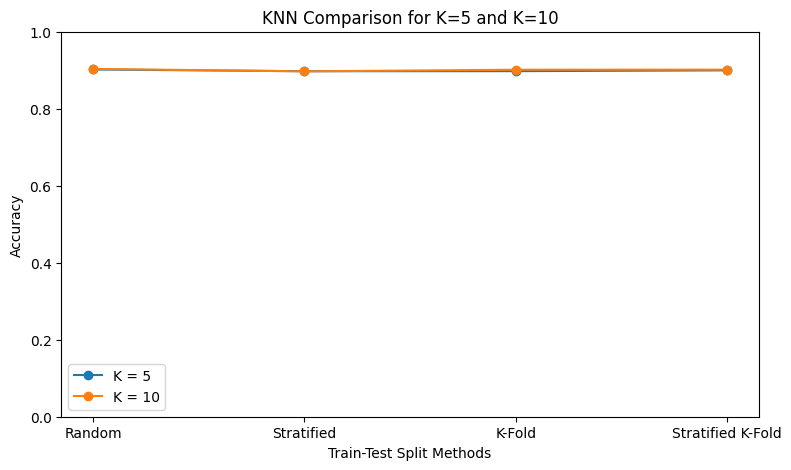

In [123]:
labels = ["Random", "Stratified", "K-Fold", "Stratified K-Fold"]

plt.figure(figsize=(9,5))
plt.plot(labels, accuracies_knn5, marker='o', label="K = 5")
plt.plot(labels, [acc_knn10_random, acc_knn10_strat, acc_knn10_kfold, acc_knn10_skf],
         marker='o', label="K = 10")

plt.xlabel("Train-Test Split Methods")
plt.ylabel("Accuracy")
plt.title("KNN Comparison for K=5 and K=10")
plt.legend()
plt.ylim(0,1)
plt.show()

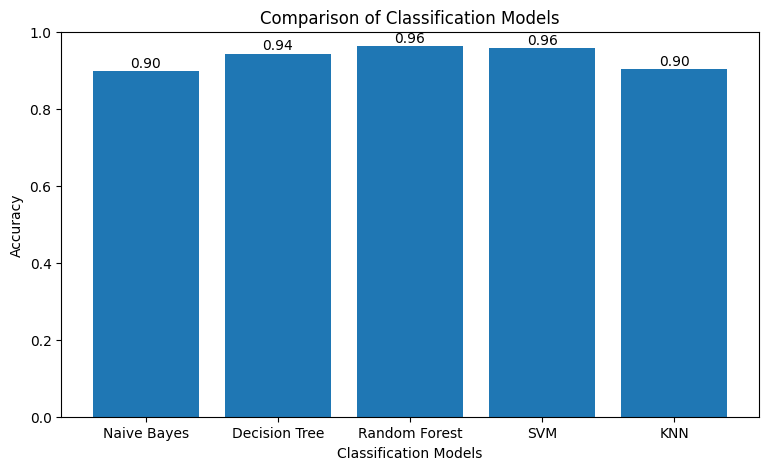

In [124]:
import matplotlib.pyplot as plt

models = [
    "Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "KNN"
]

# Retrieve accuracies from the results_df generated previously
# Assuming results_df contains the accuracy for each model
accuracies = [
    results_df.loc[results_df['Model'] == 'Naive Bayes', 'Accuracy'].values[0],
    results_df.loc[results_df['Model'] == 'Decision Tree', 'Accuracy'].values[0],
    results_df.loc[results_df['Model'] == 'Random Forest', 'Accuracy'].values[0],
    results_df.loc[results_df['Model'] == 'SVM', 'Accuracy'].values[0],
    results_df.loc[results_df['Model'] == 'KNN_k10', 'Accuracy'].values[0] # Using KNN_k10 as it showed better performance
]

plt.figure(figsize=(9,5))
bars = plt.bar(models, accuracies)

plt.xlabel("Classification Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Classification Models")
plt.ylim(0,1)

# Show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.2f}",
             ha='center')

plt.show()

In [125]:
from sklearn.preprocessing import StandardScaler

# Select numerical features only
X = df.select_dtypes(include=['float64','int64'])

# Scaling is very important for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

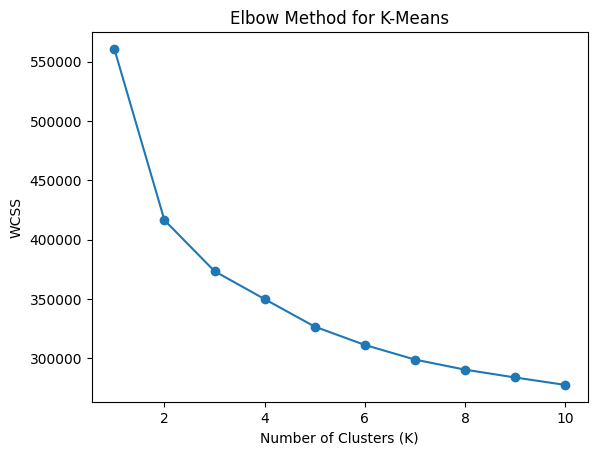

In [126]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")
plt.show()

In [127]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

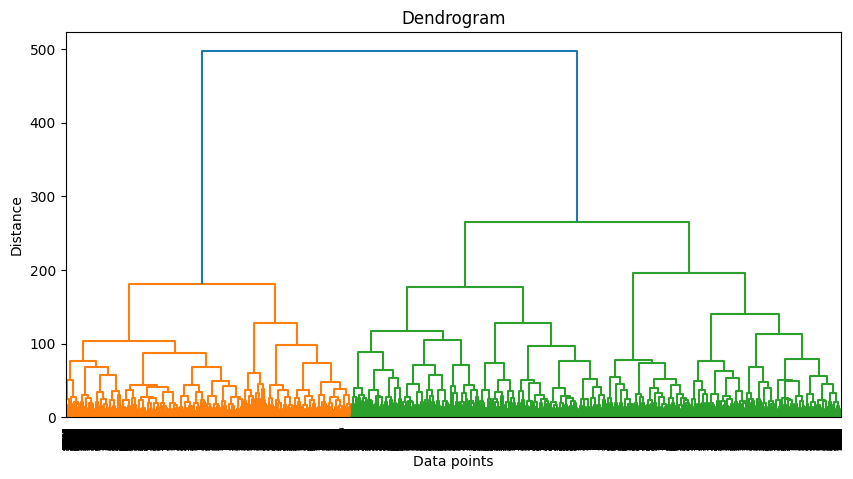

In [128]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

In [129]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hc_labels

In [130]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

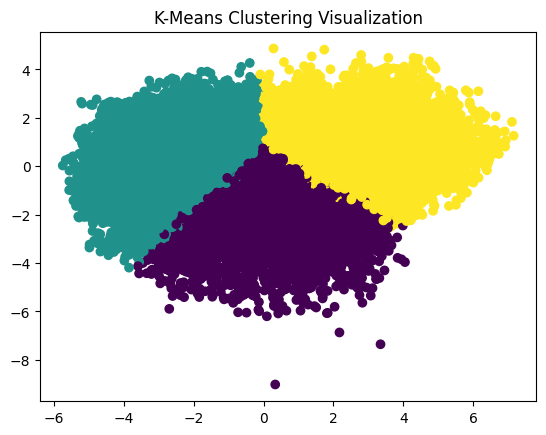

In [131]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clustering Visualization")
plt.show()

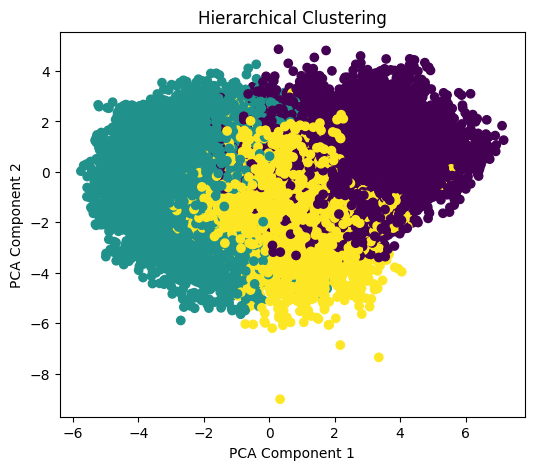

In [132]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

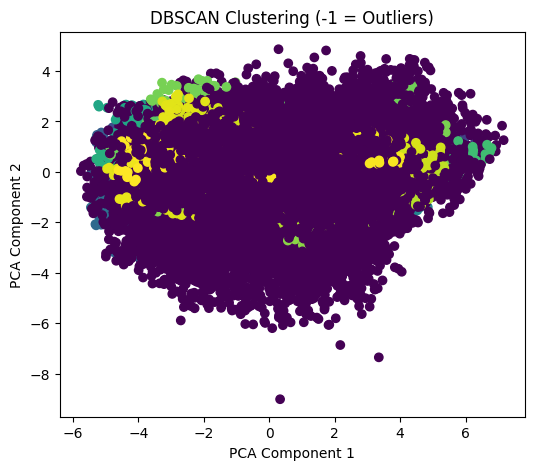

In [133]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering (-1 = Outliers)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [134]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [135]:
results = []

# ---------- K-Means ----------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)

results.append(["K-Means", sil_kmeans, db_kmeans])


# ---------- Hierarchical ----------
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, hc_labels)
db_hc = davies_bouldin_score(X_scaled, hc_labels)

results.append(["Hierarchical", sil_hc, db_hc])


# ---------- DBSCAN ----------
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# Remove noise (-1) for metric calculation
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
    db_db = davies_bouldin_score(X_scaled[mask], db_labels[mask])
else:
    sil_db = "Not valid"
    db_db = "Not valid"

results.append(["DBSCAN", sil_db, db_db])

In [136]:
comparison_df = pd.DataFrame(
    results,
    columns=["Algorithm", "Silhouette Score", "Davies-Bouldin Index"]
)

print(comparison_df)

      Algorithm  Silhouette Score  Davies-Bouldin Index
0       K-Means          0.183847              1.978030
1  Hierarchical          0.126266              2.486514
2        DBSCAN          0.351221              0.865677


In [138]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ensure X and y_cat are defined for splitting if they are not already.
# This assumes 'df' is available, which it should be based on kernel state.
if 'df' not in globals():
    raise NameError("DataFrame 'df' not found. Please ensure it's loaded and preprocessed.")

X = df.drop(columns=["time", "total_load_actual"])
y_cat = pd.qcut(df["total_load_actual"], q=3, labels=["Low", "Medium", "High"])

# Split the data into training and testing sets for classification
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

# Convert categorical labels to numerical integers for Keras
y_train_cat_int = y_train_cat.cat.codes
y_test_cat_int = y_test_cat.cat.codes

# Build ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: Low, Medium, High
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train_cat_int, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

# Predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Evaluation
print("Accuracy:", accuracy_score(y_test_cat_int, y_pred_classes))
print(classification_report(y_test_cat_int, y_pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9453481735159818
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2266
           1       0.93      0.91      0.92      2388
           2       0.97      0.94      0.95      2354

    accuracy                           0.95      7008
   macro avg       0.95      0.95      0.95      7008
weighted avg       0.95      0.95      0.95      7008



In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd

In [140]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train_cat)

# Predict
rf_pred = rf.predict(X_test)

# Metrics
rf_acc = accuracy_score(y_test_cat, rf_pred)
rf_prec = precision_score(y_test_cat, rf_pred, average='weighted')
rf_rec = recall_score(y_test_cat, rf_pred, average='weighted')
rf_f1 = f1_score(y_test_cat, rf_pred, average='weighted')

In [12]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Ensure X and y_cat are defined for splitting
# Assuming df is available and 'total_load_actual' is the target
if 'df' in globals():
    X = df.drop(columns=["time", "total_load_actual"])
    y_cat = pd.qcut(df["total_load_actual"], q=3, labels=["Low", "Medium", "High"])
else:
    raise NameError("DataFrame 'df' not found. Please ensure it's loaded and preprocessed.")

# Split the data into training and testing sets for classification
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, shuffle=True, random_state=42
)

# Build ANN
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

# Compile
ann.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Convert categorical labels to numerical integers for Keras
y_train_cat_int = y_train_cat.cat.codes
y_test_cat_int = y_test_cat.cat.codes

# Train
ann.fit(X_train, y_train_cat_int, epochs=10, batch_size=32, verbose=0)

# Predict
ann_pred = ann.predict(X_test)
ann_pred_classes = np.argmax(ann_pred, axis=1)

# Metrics
ann_acc = accuracy_score(y_test_cat_int, ann_pred_classes)
ann_prec = precision_score(y_test_cat_int, ann_pred_classes, average='weighted')
ann_rec = recall_score(y_test_cat_int, ann_pred_classes, average='weighted')
ann_f1 = f1_score(y_test_cat_int, ann_pred_classes, average='weighted')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [142]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load datasets
energy = pd.read_csv("energy_dataset.csv")
weather = pd.read_csv("weather_features.csv")

# Select relevant columns from weather
weather = weather[['dt_iso', 'temp', 'humidity', 'wind_speed', 'clouds_all']]

# Convert time columns to datetime objects
energy['time'] = pd.to_datetime(energy['time'], utc=True)
weather['dt_iso'] = pd.to_datetime(weather['dt_iso'], utc=True)

# Group weather data by hour
weather_hourly = weather.groupby('dt_iso').mean().reset_index()

# Merge energy and weather datasets
df = pd.merge(
    energy,
    weather_hourly,
    left_on='time',
    right_on='dt_iso',
    how='left'
)

# Drop redundant 'dt_iso' column
df.drop(columns=['dt_iso'], inplace=True)

# Rename columns for consistency and readability
df.rename(columns={
    'total load actual': 'total_load_actual',
    'total load forecast': 'total_load_forecast',
    'generation solar': 'generation_solar',
    'generation wind onshore': 'generation_wind_onshore',
    'generation fossil gas': 'generation_fossil_gas',
    'generation fossil hard coal': 'generation_fossil_hard_coal',
    'generation nuclear': 'generation_nuclear',
    'generation hydro run-of-river and poundage': 'generation_hydro',
    'price actual': 'price_actual'
}, inplace=True)

# Select the final set of features
df = df[[
    'time',
    'total_load_actual',
    'total_load_forecast',
    'generation_solar',
    'generation_wind_onshore',
    'generation_fossil_gas',
    'generation_fossil_hard_coal',
    'generation_nuclear',
    'generation_hydro',
    'price_actual',
    'temp',
    'humidity',
    'wind_speed',
    'clouds_all'
]]

# Fill missing values using forward fill
df.fillna(method='ffill', inplace=True)

# Create lagged and rolling mean features
df['load_lag1'] = df['total_load_actual'].shift(1)
df['load_lag24'] = df['total_load_actual'].shift(24)
df['load_roll3'] = df['total_load_actual'].rolling(window=3).mean()

# Drop rows with NaN values introduced by feature engineering
df.dropna(inplace=True)

# Scale numerical features
scaler = MinMaxScaler()
cols_to_scale = [
    'total_load_actual', 'total_load_forecast',
    'generation_solar', 'generation_wind_onshore',
    'generation_fossil_gas', 'generation_fossil_hard_coal',
    'generation_nuclear', 'generation_hydro',
    'price_actual', 'temp', 'humidity',
    'wind_speed', 'clouds_all',
    'load_lag1', 'load_lag24', 'load_roll3'
]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

/tmp/ipykernel_1323/4039359307.py:62: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [143]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "ANN"],
    "Accuracy": [rf_acc, ann_acc],
    "Precision": [rf_prec, ann_prec],
    "Recall": [rf_rec, ann_rec],
    "F1-Score": [rf_f1, ann_f1]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.963756   0.963732  0.963756  0.963708
1            ANN  0.944492   0.944752  0.944492  0.944229


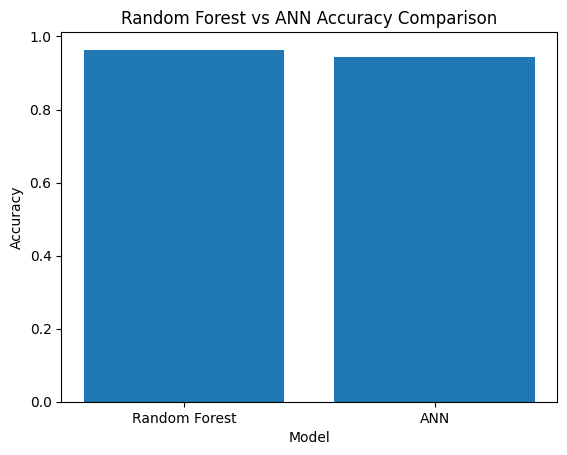

In [144]:
import matplotlib.pyplot as plt

plt.bar(comparison["Model"], comparison["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Random Forest vs ANN Accuracy Comparison")
plt.show()

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import numpy as np
import pandas as pd

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

In [148]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "KNN (k=10)": KNeighborsClassifier(n_neighbors=10),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

In [149]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

In [151]:
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

ann.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Convert y_train and y_test to numerical integer codes for Keras
y_train_int = y_train.cat.codes
y_test_int = y_test.cat.codes

ann.fit(X_train, y_train_int, epochs=10, batch_size=32, verbose=0)

# Predict
ann_pred = ann.predict(X_test)
ann_pred_classes = np.argmax(ann_pred, axis=1)

# Metrics
ann_acc = accuracy_score(y_test_int, ann_pred_classes)
ann_prec = precision_score(y_test_int, ann_pred_classes, average='weighted')
ann_rec = recall_score(y_test_int, ann_pred_classes, average='weighted')
ann_f1 = f1_score(y_test_int, ann_pred_classes, average='weighted')

results.append([
    "ANN", ann_acc, ann_prec, ann_rec, ann_f1
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [152]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score"
])

# Sort by Accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
2        Random Forest  0.962757   0.962833  0.962757  0.962789
3                  SVM  0.957334   0.957337  0.957334  0.957331
7                  ANN  0.952483   0.954154  0.952483  0.952834
6  Logistic Regression  0.948487   0.948400  0.948487  0.948437
1        Decision Tree  0.945919   0.945856  0.945919  0.945878
0          Naive Bayes  0.897831   0.897870  0.897831  0.897820
4            KNN (k=5)  0.897403   0.896672  0.897403  0.896732
5           KNN (k=10)  0.897118   0.896749  0.897118  0.895500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

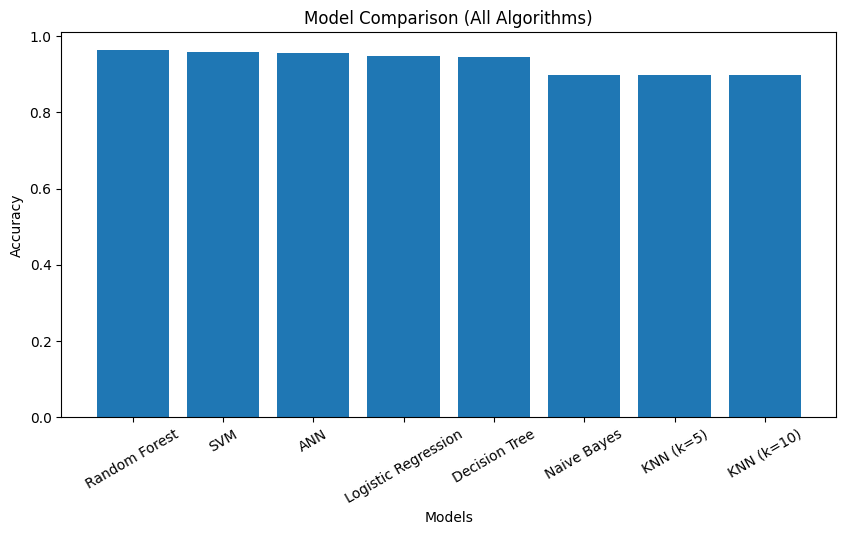

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (All Algorithms)")
plt.show()

In [155]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules


# ===============================
# 2. Copy Dataset
# ===============================
df_rules = df.copy()


# ===============================
# 3. Convert Numerical → Categorical
# ===============================
# (Important for Apriori)

df_rules['temp_cat'] = pd.qcut(df_rules['temp'], 3, labels=['Low','Medium','High'])
df_rules['humidity_cat'] = pd.qcut(df_rules['humidity'], 3, labels=['Low','Medium','High'])
df_rules['wind_cat'] = pd.qcut(df_rules['wind_speed'], 3, labels=['Low','Medium','High'])
df_rules['load_cat'] = pd.qcut(df_rules['total_load_actual'], 3, labels=['Low','Medium','High'])


# ===============================
# 4. Select Features for Rules
# ===============================
transactions = df_rules[['temp_cat', 'humidity_cat', 'wind_cat', 'load_cat']]


# ===============================
# 5. One-Hot Encoding
# ===============================
data = pd.get_dummies(transactions)


# ===============================
# 6. Apply Apriori Algorithm
# ===============================
frequent = apriori(data, min_support=0.02, use_colnames=True)

print("Frequent Itemsets:\n")
print(frequent.head())


# ===============================
# 7. Generate Association Rules
# ===============================
rules = association_rules(frequent, metric="confidence", min_threshold=0.3)

print("\nAssociation Rules:\n")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


# ===============================
# 8. Sort Best Rules (Important)
# ===============================
rules = rules.sort_values(by='lift', ascending=False)

print("\nTop Rules (Sorted by Lift):\n")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Frequent Itemsets:

    support               itemsets
0  0.333362         (temp_cat_Low)
1  0.333305      (temp_cat_Medium)
2  0.333333        (temp_cat_High)
3  0.336358     (humidity_cat_Low)
4  0.333761  (humidity_cat_Medium)

Association Rules:

                                           antecedents  \
0                                       (temp_cat_Low)   
1                                (humidity_cat_Medium)   
2                                       (temp_cat_Low)   
3                                  (humidity_cat_High)   
4                                       (temp_cat_Low)   
..                                                 ...   
325        (load_cat_Low, wind_cat_Low, temp_cat_High)   
326  (load_cat_Low, wind_cat_Low, humidity_cat_Medium)   
327  (load_cat_Low, temp_cat_High, humidity_cat_Med...   
328  (wind_cat_Low, temp_cat_High, humidity_cat_Med...   
329                      (load_cat_Low, temp_cat_High)   

                             consequents   support  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
